CatBoost

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as imbPipeline

sns.set(style="whitegrid")

## 1. Data Preprocess

1.1 Data exploration

In [7]:
df = pd.read_csv("/Users/adilkhankaldybekov/Desktop/adilkhan/Machine Learning/courses/project 1/data.csv", sep=';')

In [8]:
#Data Set observation

print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
#Counting number of nan values for each feature

print(df.isna().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [11]:
#Data observation for integer features

num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].describe()



,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## 2. Data processing/engineering ##

In [12]:
cat_cols = df.select_dtypes(include=['object']).drop(columns=['y']).columns

In [13]:
def create_prep():
    num_transformer = Pipeline(steps=[('scaler', StandardScaler())]) #for ranging variables

    cat_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]) #for categorical variables one-hot encoding  

    prep = ColumnTransformer(transformers=[('num', num_transformer, num_cols),
                                           ('cat', cat_transformer, cat_cols)])
    return prep

preprocessor = create_prep() 

According to some observations we did data exploratory analysis and feature engineering engineering(Standardize data and Encoding)

## Model

According to model evaluations it is decided to use CatBoost Classifier due to its best results and tune it

In [14]:
X = df.drop(columns='y', axis=1)


Y = (df['y'] == 'yes').astype(int)
#Y = df['y'].map({'yes': 1, 'no' : 0})


Xtrain, Xtest, Ytrain, Ytest = train_test_split( X, Y, test_size=0.2, random_state=42, stratify=Y)

In [15]:
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
import numpy as np

pipe_cb = ImbPipeline(steps=[
    ('prep',   preprocessor),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    CatBoostClassifier(verbose=0, random_state=42))
])


cv_scores_cb = cross_val_score(pipe_cb, Xtrain, Ytrain, 
                               cv=5, scoring='f1', n_jobs=-1)
print(f"CatBoost 5-Fold CV F1-score: {cv_scores_cb.mean():.3f} ± {cv_scores_cb.std():.3f}")

CatBoost 5-Fold CV F1-score: 0.596 ± 0.012


In [16]:
from sklearn.model_selection import GridSearchCV

param_grid_cb = {
    'clf__depth':          [3, 5, 7],
    'clf__learning_rate':  [0.01, 0.1, 0.2],
    'clf__iterations':     [100, 200]
}

grid_cb = GridSearchCV(pipe_cb, 
                       param_grid_cb, 
                       cv=5, 
                       scoring='f1',
                       n_jobs=-1,
                       verbose=1)
grid_cb.fit(Xtrain, Ytrain)

print("Best CatBoost Parameters:", grid_cb.best_params_)
print(f"Best CatBoost CV F1-score: {grid_cb.best_score_:.3f}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best CatBoost Parameters: {'clf__depth': 5, 'clf__iterations': 100, 'clf__learning_rate': 0.1}
Best CatBoost CV F1-score: 0.609


In [17]:
final_cb = ImbPipeline(steps=[
    ('prep',   preprocessor),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    CatBoostClassifier(
                   verbose=0,
                   random_state=42,
                   depth=5,
                   iterations=100,
                   learning_rate=0.1
               ))
])

final_cb.fit(Xtrain, Ytrain)

y_pred_cb   = final_cb.predict(Xtest)
y_proba_cb  = final_cb.predict_proba(Xtest)[:, 1]



         === Final CatBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      7985
           1       0.57      0.69      0.63      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.81      0.79      9043
weighted avg       0.91      0.90      0.91      9043

ROC AUC : 0.93


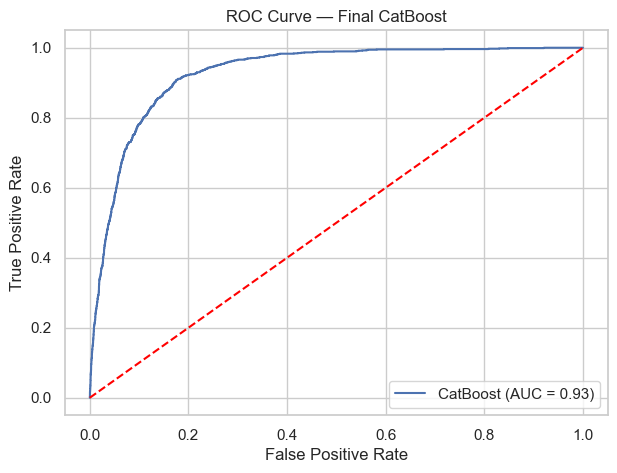

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve    

print("         === Final CatBoost Classification Report ===")
print(classification_report(Ytest, y_pred_cb))
print(f"ROC AUC : {roc_auc_score(Ytest, y_proba_cb):.2f}")

fpr, tpr, _ = roc_curve(Ytest, y_proba_cb)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {roc_auc_score(Ytest, y_proba_cb):.2f})')
plt.plot([0,1],[0,1],'--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final CatBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [19]:
import shap 
from catboost import Pool

In [20]:
XtrainPrep = final_cb.named_steps['prep'].transform(Xtrain)
feature_names = final_cb.named_steps['prep'].get_feature_names_out()

In [21]:
shap_values_with_base = final_cb.named_steps['clf'].get_feature_importance(data=Pool(XtrainPrep), type='ShapValues')

In [22]:
shap_values = shap_values_with_base[:, :-1]

In [23]:
shap_values_mean = np.abs(shap_values).mean(axis=0)

In [24]:
shap_values_mean

array([7.83509387e-02, 2.16531371e-01, 1.31364723e-01, 1.26531539e+00,
       5.85884933e-01, 9.86168331e-03, 3.98723984e-02, 3.82683080e-02,
       4.17248624e-02, 8.34268121e-03, 1.76598252e-02, 5.70955293e-02,
       0.00000000e+00, 1.91772945e-02, 2.73163423e-02, 1.32934469e-02,
       4.65946423e-02, 1.61062240e-02, 0.00000000e+00, 2.90016006e-03,
       5.21447526e-02, 4.52277225e-02, 3.80027923e-02, 1.95176101e-02,
       5.75389517e-02, 1.16747342e-02, 0.00000000e+00, 0.00000000e+00,
       8.23388461e-02, 3.27625332e-01, 1.15597911e-01, 6.40360200e-02,
       1.77431621e-01, 0.00000000e+00, 4.58428376e-01, 6.54271377e-02,
       6.62432952e-02, 9.82490758e-03, 7.24287578e-02, 4.00303072e-02,
       1.12734407e-01, 7.98708883e-02, 6.89213635e-02, 1.21767902e-01,
       5.99662550e-02, 7.40424896e-02, 4.46149907e-02, 1.66709367e-02,
       9.08997219e-04, 2.52652902e-01, 2.57893061e-02])

In [25]:
shap_df = pd.DataFrame(
    {
        'feature': feature_names,
        'shap_imp': shap_values_mean
    }
).sort_values('shap_imp', ascending=False)
                                                                                        

In [26]:
shap_df.reset_index(drop=True, inplace=True)

In [27]:
shap_df

,feature,shap_imp
0,num__duration,1.265315
1,num__campaign,0.585885
2,cat__contact_unknown,0.458428
3,cat__housing_yes,0.327625
4,cat__poutcome_success,0.252653
5,num__balance,0.216531
6,cat__contact_cellular,0.177432
7,num__day,0.131365
8,cat__month_may,0.121768
9,cat__loan_no,0.115598


In [28]:
top10_shap = shap_df.head(10)

In [29]:
top10_shap

,feature,shap_imp
0,num__duration,1.265315
1,num__campaign,0.585885
2,cat__contact_unknown,0.458428
3,cat__housing_yes,0.327625
4,cat__poutcome_success,0.252653
5,num__balance,0.216531
6,cat__contact_cellular,0.177432
7,num__day,0.131365
8,cat__month_may,0.121768
9,cat__loan_no,0.115598


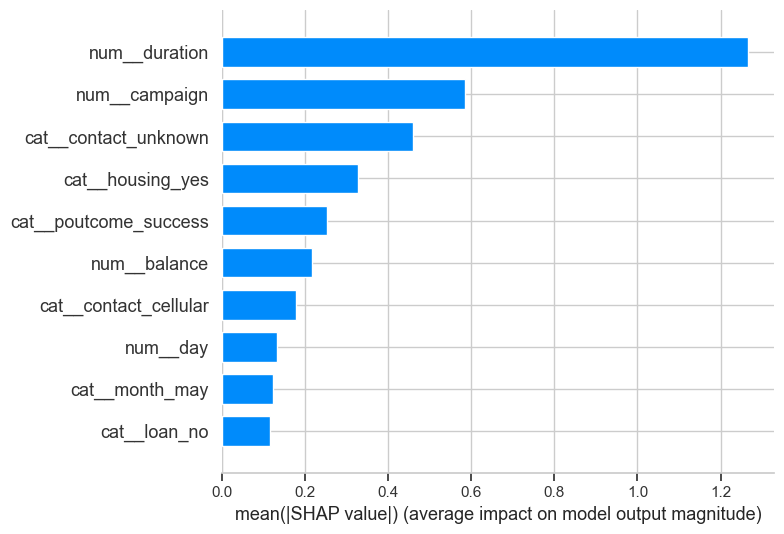

In [30]:
shap.summary_plot(shap_values, XtrainPrep, feature_names=feature_names,plot_type='bar', max_display=10)


In [31]:
top10_feat = shap_df.head(10)['feature'].tolist()
print("Top 10 features based on SHAP values:", top10_feat)

Top 10 features based on SHAP values: ['num__duration', 'num__campaign', 'cat__contact_unknown', 'cat__housing_yes', 'cat__poutcome_success', 'num__balance', 'cat__contact_cellular', 'num__day', 'cat__month_may', 'cat__loan_no']


In [32]:
feat_idx = [list(feature_names).index(f) for f in top10_feat]

XtrainTop10 = XtrainPrep[:, feat_idx]

XtestPrep  = final_cb.named_steps['prep'].transform(Xtest)
XtestTop10 = XtestPrep[:, feat_idx]



In [33]:
model_top10 = CatBoostClassifier(
                   verbose=0,
                   random_state=42,
                   depth=5,
                   iterations=100,
                   learning_rate=0.1
)

model_top10.fit(XtrainTop10, Ytrain, eval_set=(XtestTop10, Ytest), use_best_model=True)

Ypred = model_top10.predict(XtestTop10)

print("         === Final CatBoost Top 10 Features Classification Report ===")
print(classification_report(Ytest, Ypred))
print(f"ROC AUC : {roc_auc_score(Ytest, model_top10.predict_proba(XtestTop10)[:, 1]):.2f}")

         === Final CatBoost Top 10 Features Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.36      0.46      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.67      0.70      9043
weighted avg       0.89      0.90      0.89      9043

ROC AUC : 0.90


Saving model

In [ ]:
from joblib import dump

dump(model_top10, "model10_classifier_only.joblib")


['model10_classifier_only.joblib']